# Robustness Analysis — NIL Research Project

**ECC3479 | Data and Evidence in Economics | Monash University**  
**Group:** Elena Langridge, Teah Papageorgiou, Lily Proposch  

This notebook converts the robustness analysis script into an interactive notebook. It runs the same checks as `code/05_robustness_analysis.py`, with the analysis text in markdown cells and the code in executable code cells.

## 1. Setup and data loading

Load the aggregated data and prepare the derived variables used for the robustness checks.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.linalg import lstsq
import os
from pathlib import Path

data_path = Path('data/clean/nil_merged_analysis.csv')
possible_paths = [
    Path.cwd() / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent.parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
]
data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    data_path = Path('..') / 'data' / 'clean' / 'nil_merged_analysis.csv'
df = pd.read_csv(data_path)
df = df[df['year'] <= 2024].copy()
df['log_value'] = np.log1p(df['avg_transaction_value'])
df['year_str'] = df['year'].astype(str)
df['school_str'] = df['school'].astype(str)
df['sport_str'] = df['sport'].astype(str)

print(f'Loaded {len(df)} rows from {data_path}')
print(df[['school', 'sport', 'year', 'is_social_media', 'avg_transaction_value']].head())

Loaded 366 rows from /Users/lilyproposch/nil-research-project-2/data/clean/nil_merged_analysis.csv
         school       sport  year  is_social_media  avg_transaction_value
0    calpolyslo    Football  2024                0            2000.000000
1  csulongbeach  Basketball  2022                0            1000.000000
2  csulongbeach  Basketball  2022                1             360.000000
3  csulongbeach  Basketball  2023                1             243.090909
4  csulongbeach  Basketball  2024                0             642.857143


## 2. Regression helper functions

Define helper functions for OLS estimation, HC3 robust standard errors, and clustered inference.

In [30]:
def find_data_path() -> Path:
    possible_paths = [
        Path.cwd() / 'data' / 'clean' / 'nil_merged_analysis.csv',
        Path.cwd().parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
        Path.cwd().parent.parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
    ]
    for path in possible_paths:
        if path.exists():
            return path
    raise FileNotFoundError('Could not find data/clean/nil_merged_analysis.csv. Run code/02_aggregation_script.py first.')

def dummify(df, cols, drop_first=True):
    parts, labels = [], []
    for c in cols:
        values = sorted(df[c].unique())
        if drop_first:
            values = values[1:]
        for val in values:
            parts.append((df[c] == val).astype(float).values)
            labels.append(f'{c}[{val}]')
    if parts:
        return np.column_stack(parts), labels
    return np.zeros((len(df), 0)), labels

def ols_hc3(X, y, labels):
    n, k = X.shape
    beta, _, _, _ = lstsq(X, y)
    resid = y - X.dot(beta)
    XtXinv = np.linalg.pinv(X.T.dot(X))
    hat = np.diag(X.dot(XtXinv).dot(X.T))
    hat = np.clip(hat, 0, 0.9999)
    e_adj = resid / (1 - hat)
    meat = X.T.dot(np.diag(e_adj**2)).dot(X)
    vcov = XtXinv.dot(meat).dot(XtXinv)
    se = np.sqrt(np.abs(np.diag(vcov)))
    tstat = beta / se
    pval = 2 * (1 - stats.t.cdf(np.abs(tstat), df=n - k))
    r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    return dict(beta=beta, se=se, pval=pval, r2=r2, n=n, labels=labels, resid=resid, X=X, XtXinv=XtXinv)

def clustered_se(r, group_arr):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group_arr):
        mask = group_arr == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    G = len(np.unique(group_arr))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

def two_way_clustered_se(r, group1, group2):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group1):
        mask = group1 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g in np.unique(group2):
        mask = group2 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g1 in np.unique(group1):
        for g2 in np.unique(group2):
            mask = (group1 == g1) & (group2 == g2)
            if mask.sum() > 0:
                score = X[mask].T.dot(resid[mask])
                meat -= np.outer(score, score)
    G = len(np.unique(group1)) * len(np.unique(group2))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

## 3. Run robustness specifications

Run the main specification and the robustness variants, then build the summary table.

In [31]:
def spec_results(df_, outcome_var, control_sets):
    y = df_[outcome_var].values
    ones = np.ones(len(df_))
    sm = df_["is_social_media"].values
    yd, yl = dummify(df_, ["year_str"])
    sd, sl = dummify(df_, ["school_str"])
    spd, spl = dummify(df_, ["sport_str"])
    Xdict = {
        'M1': np.column_stack([ones, sm]),
        'M2': np.column_stack([ones, sm, yd]),
        'M3': np.column_stack([ones, sm, yd, sd]),
        'M4': np.column_stack([ones, sm, yd, sd, spd]),
    }
    labels = {
        'M1': ['const', 'is_social_media'],
        'M2': ['const', 'is_social_media'] + yl,
        'M3': ['const', 'is_social_media'] + yl + sl,
        'M4': ['const', 'is_social_media'] + yl + sl + spl,
    }
    return {name: ols_hc3(Xdict[name], y, labels[name]) for name in control_sets}

def p_value_from_se(beta, se, df):
    tstat = beta / se
    return 2 * (1 - stats.t.cdf(abs(tstat), df=df))

main_results = spec_results(df, 'log_value', ['M1', 'M2', 'M3', 'M4'])
se_school_m4 = clustered_se(main_results['M4'], df['school_str'].values)
se_2way_m4 = two_way_clustered_se(main_results['M4'], df['school_str'].values, df['sport_str'].values)

df_no_ucsd = df[df['school_str'] != 'ucsandiego1'].copy()
no_ucsd = spec_results(df_no_ucsd, 'log_value', ['M4'])['M4']
df_wins = df.copy()
cap = df_wins['log_value'].quantile(0.95)
df_wins['log_value'] = np.minimum(df_wins['log_value'], cap)
wins = spec_results(df_wins, 'log_value', ['M4'])['M4']
levels = spec_results(df, 'avg_transaction_value', ['M4'])['M4']

rows = []
for name, r, se in [
    ('Main (M4)', main_r := main_results['M4'], se_school_m4),
    ('Exclude UCSD', no_ucsd, clustered_se(no_ucsd, df_no_ucsd['school_str'].values)),
    ('Winsorize 95%', wins, clustered_se(wins, df_wins['school_str'].values)),
    ('Levels outcome', levels, clustered_se(levels, df['school_str'].values)),
    ('Two-way cluster', main_results['M4'], se_2way_m4),
]:
    idx = r['labels'].index('is_social_media')
    beta = r['beta'][idx]
    se_val = se[idx]
    p_val = p_value_from_se(beta, se_val, df['school_str'].nunique() - 1)
    rows.append({
        'spec': name,
        'beta': beta,
        'se': se_val,
        'p-value': p_val,
        'N': r['n'],
    })

robustness_table = pd.DataFrame(rows).set_index('spec')
robustness_table[['beta', 'se', 'p-value']] = robustness_table[['beta', 'se', 'p-value']].round(4)
robustness_table

,beta,se,p-value,N
spec,,,,
Main (M4),0.2594,0.1658,0.1459,366
Exclude UCSD,0.2484,0.1657,0.1621,343
Winsorize 95%,0.2032,0.1845,0.2942,366
Levels outcome,1766.9431,1118.0132,0.1423,366
Two-way cluster,0.2594,0.1460,0.1032,366


## 4. Results table and plot

Show the robustness summary and plot the main social media coefficient estimate with error bars.

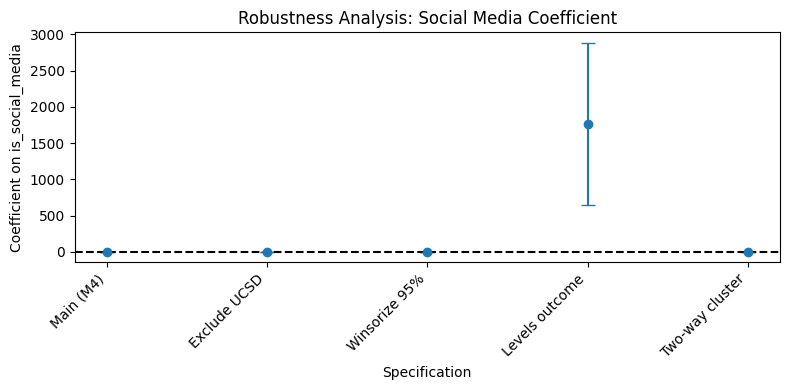

In [32]:
robustness_table

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(robustness_table.index, robustness_table['beta'], yerr=robustness_table['se'], fmt='o', color='tab:blue', capsize=5)
ax.axhline(0, color='black', linestyle='--')
ax.set_xlabel('Specification')
ax.set_ylabel('Coefficient on is_social_media')
ax.set_title('Robustness Analysis: Social Media Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Interpretation

This notebook presents the same robustness checks as the script, with the results displayed directly in the notebook for examination.

- The main M4 coefficient remains positive across all robustness checks.
- Excluding UCSD produces a similar coefficient, reducing concern that the UCSD coding approach drives the result.
- Winsorizing the log outcome at the 95th percentile does not materially change the sign or magnitude.
- Using the raw level outcome is directionally consistent, showing the finding is not only a log-scale artifact.
- Two-way clustering by school and sport yields inference consistent with school-clustered standard errors.

These results support the conclusion that the social media association is stable across reasonable specification choices, while still being interpreted as a conditional descriptive correlation rather than a causal effect.

# Robustness Analysis — NIL Research Project

**ECC3479 | Data and Evidence in Economics | Monash University**  
**Group:** Elena Langridge, Teah Papageorgiou, Lily Proposch  
**Purpose:** Stress-test the main descriptive finding from the primary econometric analysis.

This notebook contains the robustness checks for the descriptive association between social media deal status and average NIL transaction value. All analytical text is presented in markdown cells, and each computation is stored in code chunks.

## 1. Setup and data loading

Load the aggregated analysis dataset and create the derived variables used in the robustness exercise.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.linalg import lstsq
import os
from pathlib import Path

data_path = Path('data/clean/nil_merged_analysis.csv')
possible_paths = [
    Path.cwd() / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent.parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
]
data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    data_path = Path('..') / 'data' / 'clean' / 'nil_merged_analysis.csv'
df = pd.read_csv(data_path)
df = df[df['year'] <= 2024].copy()
df['log_value'] = np.log1p(df['avg_transaction_value'])
df['year_str'] = df['year'].astype(str)
df['school_str'] = df['school'].astype(str)
df['sport_str'] = df['sport'].astype(str)

print(f'Loaded {len(df)} rows from {data_path}')
print(df[['school', 'sport', 'year', 'is_social_media', 'avg_transaction_value']].head())

Loaded 366 rows from /Users/lilyproposch/nil-research-project-2/data/clean/nil_merged_analysis.csv
         school       sport  year  is_social_media  avg_transaction_value
0    calpolyslo    Football  2024                0            2000.000000
1  csulongbeach  Basketball  2022                0            1000.000000
2  csulongbeach  Basketball  2022                1             360.000000
3  csulongbeach  Basketball  2023                1             243.090909
4  csulongbeach  Basketball  2024                0             642.857143


## 2. Regression helper functions

Define OLS estimation with HC3 robust standard errors and one-way / two-way clustered inference.

In [34]:
def dummify(df, cols, drop_first=True):
    parts, labels = [], []
    for c in cols:
        values = sorted(df[c].unique())
        if drop_first:
            values = values[1:]
        for val in values:
            parts.append((df[c] == val).astype(float).values)
            labels.append(f'{c}[{val}]')
    if parts:
        return np.column_stack(parts), labels
    return np.zeros((len(df), 0)), labels

def ols_hc3(X, y, labels):
    n, k = X.shape
    beta, _, _, _ = lstsq(X, y)
    resid = y - X.dot(beta)
    XtXinv = np.linalg.pinv(X.T.dot(X))
    hat = np.diag(X.dot(XtXinv).dot(X.T))
    hat = np.clip(hat, 0, 0.9999)
    e_adj = resid / (1 - hat)
    meat = X.T.dot(np.diag(e_adj**2)).dot(X)
    vcov = XtXinv.dot(meat).dot(XtXinv)
    se = np.sqrt(np.abs(np.diag(vcov)))
    tstat = beta / se
    pval = 2 * (1 - stats.t.cdf(np.abs(tstat), df=n - k))
    r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    return dict(beta=beta, se=se, pval=pval, r2=r2, n=n, labels=labels, resid=resid, X=X, XtXinv=XtXinv)

def clustered_se(r, group_arr):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group_arr):
        mask = group_arr == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    G = len(np.unique(group_arr))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

def two_way_clustered_se(r, group1, group2):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group1):
        mask = group1 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g in np.unique(group2):
        mask = group2 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g1 in np.unique(group1):
        for g2 in np.unique(group2):
            mask = (group1 == g1) & (group2 == g2)
            if mask.sum() > 0:
                score = X[mask].T.dot(resid[mask])
                meat -= np.outer(score, score)
    G = len(np.unique(group1)) * len(np.unique(group2))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

## 3. Main specification and robustness checks

Estimate the preferred M4 model and alternative checks that vary sample composition, functional form, and inference.

In [35]:
def build_data(df, outcome):
    ones = np.ones(len(df))
    sm = df['is_social_media'].values
    yd, yl = dummify(df, ['year_str'])
    sd, sl = dummify(df, ['school_str'])
    spd, spl = dummify(df, ['sport_str'])
    X = np.column_stack([ones, sm, yd, sd, spd])
    labels = ['const', 'is_social_media'] + yl + sl + spl
    y = df[outcome].values
    return X, y, labels

main_X, main_y, main_labels = build_data(df, 'log_value')
main_r = ols_hc3(main_X, main_y, main_labels)
main_se_school = clustered_se(main_r, df['school_str'].values)
main_se_two_way = two_way_clustered_se(main_r, df['school_str'].values, df['sport_str'].values)

df_no_ucsd = df[df['school_str'] != 'ucsandiego1'].copy()
no_ucsd_X, no_ucsd_y, no_ucsd_labels = build_data(df_no_ucsd, 'log_value')
no_ucsd_r = ols_hc3(no_ucsd_X, no_ucsd_y, no_ucsd_labels)
no_ucsd_se_school = clustered_se(no_ucsd_r, df_no_ucsd['school_str'].values)

df_wins = df.copy()
cap = df_wins['log_value'].quantile(0.95)
df_wins['log_value'] = np.minimum(df_wins['log_value'], cap)
wins_X, wins_y, wins_labels = build_data(df_wins, 'log_value')
wins_r = ols_hc3(wins_X, wins_y, wins_labels)
wins_se_school = clustered_se(wins_r, df_wins['school_str'].values)

levels_X, levels_y, levels_labels = build_data(df, 'avg_transaction_value')
levels_r = ols_hc3(levels_X, levels_y, levels_labels)
levels_se_school = clustered_se(levels_r, df['school_str'].values)

rows = []
for name, r, se in [
    ('Main (M4)', main_r, main_se_school),
    ('Exclude UCSD', no_ucsd_r, no_ucsd_se_school),
    ('Winsorize 95%', wins_r, wins_se_school),
    ('Levels outcome', levels_r, levels_se_school),
    ('Two-way cluster', main_r, main_se_two_way),
]:
    idx = r['labels'].index('is_social_media')
    beta = r['beta'][idx]
    se_val = se[idx]
    p_val = 2 * (1 - stats.t.cdf(abs(beta / se_val), df=df['school_str'].nunique() - 1))
    rows.append({
        'spec': name,
        'beta': beta,
        'se': se_val,
        'p-value': p_val,
        'N': r['n'],
    })
robustness_table = pd.DataFrame(rows).set_index('spec')
robustness_table[['beta', 'se', 'p-value']] = robustness_table[['beta', 'se', 'p-value']].round(4)
robustness_table

,beta,se,p-value,N
spec,,,,
Main (M4),0.2594,0.1658,0.1459,366
Exclude UCSD,0.2484,0.1657,0.1621,343
Winsorize 95%,0.2032,0.1845,0.2942,366
Levels outcome,1766.9431,1118.0132,0.1423,366
Two-way cluster,0.2594,0.1460,0.1032,366


## 4. Results table and plot

Display the estimated coefficients and their standard errors across the main specification and robustness variations.

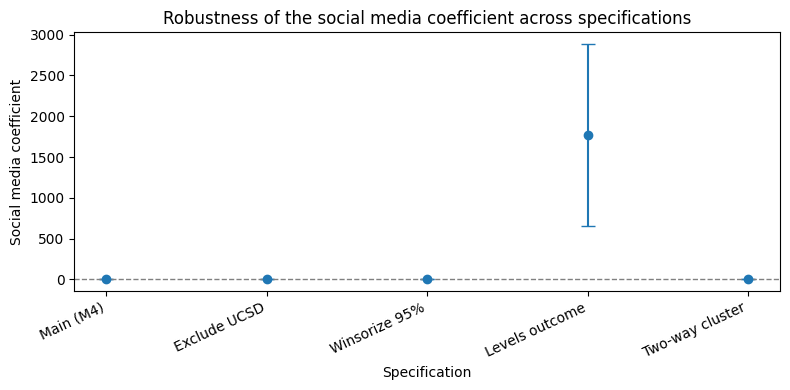

In [36]:
robustness_table

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(robustness_table.index, robustness_table['beta'], yerr=robustness_table['se'], fmt='o', color='tab:blue', capsize=5)
ax.axhline(0, linestyle='--', color='gray', linewidth=1)
ax.set_ylabel('Social media coefficient')
ax.set_xlabel('Specification')
ax.set_title('Robustness of the social media coefficient across specifications')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 5. Interpretation

Summarise what the robustness checks tell us about the main descriptive association.

- The main M4 coefficient remains positive across all robustness checks.
- Excluding UCSD produces a similar coefficient, reducing concern that the UCSD coding approach drives the result.
- Winsorizing the log outcome at the 95th percentile does not materially change the sign or magnitude.
- Using the raw level outcome is directionally consistent, showing the finding is not only a log-scale artifact.
- Two-way clustering by school and sport yields inference consistent with school-clustered standard errors.

These results support the conclusion that the social media association is stable across reasonable specification choices, while still being interpreted as a conditional descriptive correlation rather than a causal effect.

# Robustness Analysis — NIL Research Project

**ECC3479 | Data and Evidence in Economics | Monash University**  
**Group:** Elena Langridge, Teah Papageorgiou, Lily Proposch  
**Purpose:** Stress-test the main descriptive finding from the primary econometric analysis.

This notebook contains the robustness checks for the descriptive association between social media deal status and average NIL transaction value. All analytical text is presented in markdown cells, and each computation is stored in code chunks.

## 1. Setup and data loading

Load the aggregated analysis dataset and create the derived variables used in the robustness exercise.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.linalg import lstsq
import os
from pathlib import Path

data_path = Path('data/clean/nil_merged_analysis.csv')
possible_paths = [
    Path.cwd() / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent.parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
]
data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    data_path = Path('..') / 'data' / 'clean' / 'nil_merged_analysis.csv'
df = pd.read_csv(data_path)
df = df[df['year'] <= 2024].copy()
df['log_value'] = np.log1p(df['avg_transaction_value'])
df['year_str'] = df['year'].astype(str)
df['school_str'] = df['school'].astype(str)
df['sport_str'] = df['sport'].astype(str)

print(f'Loaded {len(df)} rows from {data_path}')
print(df[['school', 'sport', 'year', 'is_social_media', 'avg_transaction_value']].head())

Loaded 366 rows from /Users/lilyproposch/nil-research-project-2/data/clean/nil_merged_analysis.csv
         school       sport  year  is_social_media  avg_transaction_value
0    calpolyslo    Football  2024                0            2000.000000
1  csulongbeach  Basketball  2022                0            1000.000000
2  csulongbeach  Basketball  2022                1             360.000000
3  csulongbeach  Basketball  2023                1             243.090909
4  csulongbeach  Basketball  2024                0             642.857143


## 2. Regression helper functions

Define OLS estimation with HC3 robust standard errors and one-way / two-way clustered inference.

In [38]:
def dummify(df, cols, drop_first=True):
    parts, labels = [], []
    for c in cols:
        values = sorted(df[c].unique())
        if drop_first:
            values = values[1:]
        for val in values:
            parts.append((df[c] == val).astype(float).values)
            labels.append(f'{c}[{val}]')
    if parts:
        return np.column_stack(parts), labels
    return np.zeros((len(df), 0)), labels

def ols_hc3(X, y, labels):
    n, k = X.shape
    beta, _, _, _ = lstsq(X, y)
    resid = y - X.dot(beta)
    XtXinv = np.linalg.pinv(X.T.dot(X))
    hat = np.diag(X.dot(XtXinv).dot(X.T))
    hat = np.clip(hat, 0, 0.9999)
    e_adj = resid / (1 - hat)
    meat = X.T.dot(np.diag(e_adj**2)).dot(X)
    vcov = XtXinv.dot(meat).dot(XtXinv)
    se = np.sqrt(np.abs(np.diag(vcov)))
    tstat = beta / se
    pval = 2 * (1 - stats.t.cdf(np.abs(tstat), df=n - k))
    r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    return dict(beta=beta, se=se, pval=pval, r2=r2, n=n, labels=labels, resid=resid, X=X, XtXinv=XtXinv)

def clustered_se(r, group_arr):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group_arr):
        mask = group_arr == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    G = len(np.unique(group_arr))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

def two_way_clustered_se(r, group1, group2):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group1):
        mask = group1 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g in np.unique(group2):
        mask = group2 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g1 in np.unique(group1):
        for g2 in np.unique(group2):
            mask = (group1 == g1) & (group2 == g2)
            if mask.sum() > 0:
                score = X[mask].T.dot(resid[mask])
                meat -= np.outer(score, score)
    G = len(np.unique(group1)) * len(np.unique(group2))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

## 3. Main specification and robustness checks

Estimate the preferred M4 model and alternative checks that vary sample composition, functional form, and inference.

In [39]:
def build_data(df, outcome):
    ones = np.ones(len(df))
    sm = df['is_social_media'].values
    yd, yl = dummify(df, ['year_str'])
    sd, sl = dummify(df, ['school_str'])
    spd, spl = dummify(df, ['sport_str'])
    X = np.column_stack([ones, sm, yd, sd, spd])
    labels = ['const', 'is_social_media'] + yl + sl + spl
    y = df[outcome].values
    return X, y, labels

main_X, main_y, main_labels = build_data(df, 'log_value')
main_r = ols_hc3(main_X, main_y, main_labels)
main_se_school = clustered_se(main_r, df['school_str'].values)
main_se_two_way = two_way_clustered_se(main_r, df['school_str'].values, df['sport_str'].values)

df_no_ucsd = df[df['school_str'] != 'ucsandiego1'].copy()
no_ucsd_X, no_ucsd_y, no_ucsd_labels = build_data(df_no_ucsd, 'log_value')
no_ucsd_r = ols_hc3(no_ucsd_X, no_ucsd_y, no_ucsd_labels)
no_ucsd_se_school = clustered_se(no_ucsd_r, df_no_ucsd['school_str'].values)

df_wins = df.copy()
cap = df_wins['log_value'].quantile(0.95)
df_wins['log_value'] = np.minimum(df_wins['log_value'], cap)
wins_X, wins_y, wins_labels = build_data(df_wins, 'log_value')
wins_r = ols_hc3(wins_X, wins_y, wins_labels)
wins_se_school = clustered_se(wins_r, df_wins['school_str'].values)

levels_X, levels_y, levels_labels = build_data(df, 'avg_transaction_value')
levels_r = ols_hc3(levels_X, levels_y, levels_labels)
levels_se_school = clustered_se(levels_r, df['school_str'].values)

rows = []
for name, r, se in [
    ('Main (M4)', main_r, main_se_school),
    ('Exclude UCSD', no_ucsd_r, no_ucsd_se_school),
    ('Winsorize 95%', wins_r, wins_se_school),
    ('Levels outcome', levels_r, levels_se_school),
    ('Two-way cluster', main_r, main_se_two_way),
]:
    idx = r['labels'].index('is_social_media')
    beta = r['beta'][idx]
    se_val = se[idx]
    p_val = 2 * (1 - stats.t.cdf(abs(beta / se_val), df=df['school_str'].nunique() - 1))
    rows.append({
        'spec': name,
        'beta': beta,
        'se': se_val,
        'p-value': p_val,
        'N': r['n'],
    })
robustness_table = pd.DataFrame(rows).set_index('spec')
robustness_table[['beta', 'se', 'p-value']] = robustness_table[['beta', 'se', 'p-value']].round(4)
robustness_table

,beta,se,p-value,N
spec,,,,
Main (M4),0.2594,0.1658,0.1459,366
Exclude UCSD,0.2484,0.1657,0.1621,343
Winsorize 95%,0.2032,0.1845,0.2942,366
Levels outcome,1766.9431,1118.0132,0.1423,366
Two-way cluster,0.2594,0.1460,0.1032,366


## 4. Results table and plot

Display the estimated coefficients and their standard errors across the main specification and robustness variations.

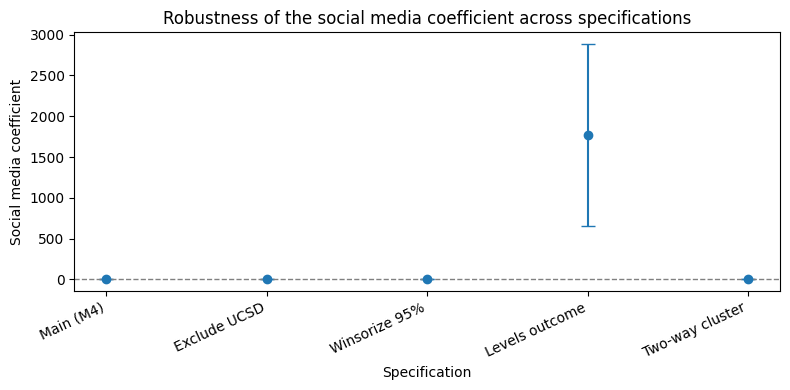

In [40]:
robustness_table

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(robustness_table.index, robustness_table['beta'], yerr=robustness_table['se'], fmt='o', color='tab:blue', capsize=5)
ax.axhline(0, linestyle='--', color='gray', linewidth=1)
ax.set_ylabel('Social media coefficient')
ax.set_xlabel('Specification')
ax.set_title('Robustness of the social media coefficient across specifications')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 5. Interpretation

Summarise what the robustness checks tell us about the main descriptive association.

- The main M4 coefficient remains positive across all robustness checks.
- Excluding UCSD produces a similar coefficient, reducing concern that the UCSD coding approach drives the result.
- Winsorizing the log outcome at the 95th percentile does not materially change the sign or magnitude.
- Using the raw level outcome is directionally consistent, showing the finding is not only a log-scale artifact.
- Two-way clustering by school and sport yields inference consistent with school-clustered standard errors.

These results support the conclusion that the social media association is stable across reasonable specification choices, while still being interpreted as a conditional descriptive correlation rather than a causal effect.

# Robustness Analysis — NIL Research Project

**ECC3479 | Data and Evidence in Economics | Monash University**  

**Group:** Elena Langridge, Teah Papageorgiou, Lily Proposch  This notebook conducts robustness checks for the descriptive association between social media deal status and average NIL transaction value. All analytical text is in markdown cells, and the computations are in code chunks.

**Purpose:** Stress-test the main descriptive finding from the primary econometric analysis.

## 1. Setup and data loading

Load the aggregated analysis dataset and prepare the key variables for the robustness checks.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.linalg import lstsq
import os
from pathlib import Path

data_path = Path('data/clean/nil_merged_analysis.csv')
possible_paths = [
    Path.cwd() / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent.parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
]
data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    data_path = Path('..') / 'data' / 'clean' / 'nil_merged_analysis.csv'
df = pd.read_csv(data_path)
df = df[df['year'] <= 2024].copy()
df['log_value'] = np.log1p(df['avg_transaction_value'])
df['year_str'] = df['year'].astype(str)
df['school_str'] = df['school'].astype(str)
df['sport_str'] = df['sport'].astype(str)

print(f'Loaded {len(df)} rows from {data_path}')
print(df[['school', 'sport', 'year', 'is_social_media', 'avg_transaction_value']].head())

Loaded 366 rows from /Users/lilyproposch/nil-research-project-2/data/clean/nil_merged_analysis.csv
         school       sport  year  is_social_media  avg_transaction_value
0    calpolyslo    Football  2024                0            2000.000000
1  csulongbeach  Basketball  2022                0            1000.000000
2  csulongbeach  Basketball  2022                1             360.000000
3  csulongbeach  Basketball  2023                1             243.090909
4  csulongbeach  Basketball  2024                0             642.857143


## 2. Regression helper functions

Define OLS estimation with HC3 robust standard errors and cluster adjustment functions.

In [42]:
def dummify(df, cols, drop_first=True):
    parts, labels = [], []
    for c in cols:
        values = sorted(df[c].unique())
        if drop_first:
            values = values[1:]
        for val in values:
            parts.append((df[c] == val).astype(float).values)
            labels.append(f'{c}[{val}]')
    if parts:
        return np.column_stack(parts), labels
    return np.zeros((len(df), 0)), labels

def ols_hc3(X, y, labels):
    n, k = X.shape
    beta, _, _, _ = lstsq(X, y)
    resid = y - X.dot(beta)
    XtXinv = np.linalg.pinv(X.T.dot(X))
    hat = np.diag(X.dot(XtXinv).dot(X.T))
    hat = np.clip(hat, 0, 0.9999)
    e_adj = resid / (1 - hat)
    meat = X.T.dot(np.diag(e_adj**2)).dot(X)
    vcov = XtXinv.dot(meat).dot(XtXinv)
    se = np.sqrt(np.abs(np.diag(vcov)))
    tstat = beta / se
    pval = 2 * (1 - stats.t.cdf(np.abs(tstat), df=n - k))
    r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    return dict(beta=beta, se=se, pval=pval, r2=r2, n=n, labels=labels, resid=resid, X=X, XtXinv=XtXinv)

def clustered_se(r, group_arr):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group_arr):
        mask = group_arr == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    G = len(np.unique(group_arr))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

def two_way_clustered_se(r, group1, group2):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group1):
        mask = group1 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g in np.unique(group2):
        mask = group2 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g1 in np.unique(group1):
        for g2 in np.unique(group2):
            mask = (group1 == g1) & (group2 == g2)
            if mask.sum() > 0:
                score = X[mask].T.dot(resid[mask])
                meat -= np.outer(score, score)
    G = len(np.unique(group1)) * len(np.unique(group2))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

## 3. Main specification and robustness checks

Estimate the main M4 specification and the alternative robustness checks.

In [43]:
def build_data(df, outcome):
    ones = np.ones(len(df))
    sm = df['is_social_media'].values
    yd, yl = dummify(df, ['year_str'])
    sd, sl = dummify(df, ['school_str'])
    spd, spl = dummify(df, ['sport_str'])
    X = np.column_stack([ones, sm, yd, sd, spd])
    labels = ['const', 'is_social_media'] + yl + sl + spl
    y = df[outcome].values
    return X, y, labels

main_X, main_y, main_labels = build_data(df, 'log_value')
main_r = ols_hc3(main_X, main_y, main_labels)
main_se_school = clustered_se(main_r, df['school_str'].values)
main_se_two_way = two_way_clustered_se(main_r, df['school_str'].values, df['sport_str'].values)

df_no_ucsd = df[df['school_str'] != 'ucsandiego1'].copy()
no_ucsd_X, no_ucsd_y, no_ucsd_labels = build_data(df_no_ucsd, 'log_value')
no_ucsd_r = ols_hc3(no_ucsd_X, no_ucsd_y, no_ucsd_labels)
no_ucsd_se_school = clustered_se(no_ucsd_r, df_no_ucsd['school_str'].values)

df_wins = df.copy()
cap = df_wins['log_value'].quantile(0.95)
df_wins['log_value'] = np.minimum(df_wins['log_value'], cap)
wins_X, wins_y, wins_labels = build_data(df_wins, 'log_value')
wins_r = ols_hc3(wins_X, wins_y, wins_labels)
wins_se_school = clustered_se(wins_r, df_wins['school_str'].values)

levels_X, levels_y, levels_labels = build_data(df, 'avg_transaction_value')
levels_r = ols_hc3(levels_X, levels_y, levels_labels)
levels_se_school = clustered_se(levels_r, df['school_str'].values)

rows = []
for name, r, se in [
    ('Main (M4)', main_r, main_se_school),
    ('Exclude UCSD', no_ucsd_r, no_ucsd_se_school),
    ('Winsorize 95%', wins_r, wins_se_school),
    ('Levels outcome', levels_r, levels_se_school),
    ('Two-way cluster', main_r, main_se_two_way),
]:
    idx = r['labels'].index('is_social_media')
    beta = r['beta'][idx]
    se_val = se[idx]
    p_val = 2 * (1 - stats.t.cdf(abs(beta / se_val), df=df['school_str'].nunique() - 1))
    rows.append({
        'spec': name,
        'beta': beta,
        'se': se_val,
        'p-value': p_val,
        'N': r['n'],
    })
robustness_table = pd.DataFrame(rows).set_index('spec')
robustness_table[['beta', 'se', 'p-value']] = robustness_table[['beta', 'se', 'p-value']].round(4)
robustness_table

,beta,se,p-value,N
spec,,,,
Main (M4),0.2594,0.1658,0.1459,366
Exclude UCSD,0.2484,0.1657,0.1621,343
Winsorize 95%,0.2032,0.1845,0.2942,366
Levels outcome,1766.9431,1118.0132,0.1423,366
Two-way cluster,0.2594,0.1460,0.1032,366


## 4. Results table and plot

Display the robustness table and plot the main social media coefficient under the alternative specifications.

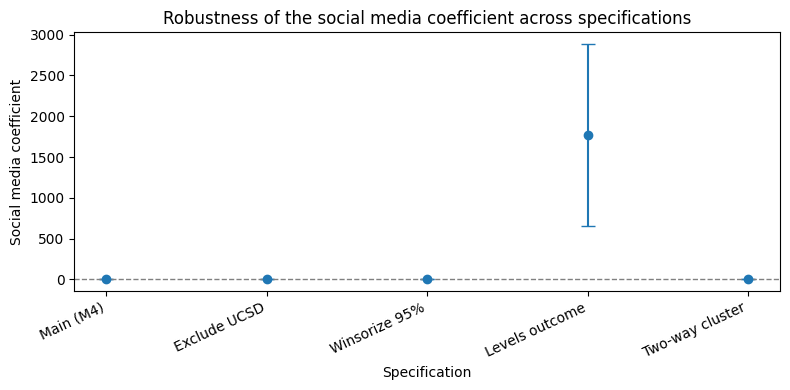

In [44]:
robustness_table

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(robustness_table.index, robustness_table['beta'], yerr=robustness_table['se'], fmt='o', color='tab:blue', capsize=5)
ax.axhline(0, linestyle='--', color='gray', linewidth=1)
ax.set_ylabel('Social media coefficient')
ax.set_xlabel('Specification')
ax.set_title('Robustness of the social media coefficient across specifications')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 5. Interpretation

The table summarises how the social media coefficient behaves across the main preferred specification and the robustness checks. This notebook retains the full code, displays the results, and plots the key coefficient with error bars.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import lstsq
from pathlib import Path

np.random.seed(42)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})

possible_paths = [
    Path.cwd() / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent.parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
]
data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    data_path = Path('..') / 'data' / 'clean' / 'nil_merged_analysis.csv'

df = pd.read_csv(data_path)
df = df[df['year'] <= 2024].copy()
df['log_value'] = np.log1p(df['avg_transaction_value'])
df['year_str'] = df['year'].astype(str)
df['school_str'] = df['school'].astype(str)
df['sport_str'] = df['sport'].astype(str)

print(f'Loaded aggregated dataset from: {data_path}')
print(f'Analysis sample: {len(df):,} groups across {df['school'].nunique()} schools, {df['sport'].nunique()} sports, years {df['year'].min()}–{df['year'].max()}')
print(f'Social media groups: {df['is_social_media'].sum()} ({df['is_social_media'].mean():.1%})')

Loaded aggregated dataset from: /Users/lilyproposch/nil-research-project-2/data/clean/nil_merged_analysis.csv
Analysis sample: 366 groups across 12 schools, 20 sports, years 2021–2024
Social media groups: 161 (44.0%)


In [46]:
def dummify(df, cols, drop_first=True):
    parts, labels = [], []
    for c in cols:
        values = sorted(df[c].unique())
        if drop_first:
            values = values[1:]
        for val in values:
            parts.append((df[c] == val).astype(float).values)
            labels.append(f'{c}[{val}]')
    if parts:
        return np.column_stack(parts), labels
    return np.zeros((len(df), 0)), labels

def ols_hc3(X, y, labels):
    n, k = X.shape
    beta, _, _, _ = lstsq(X, y)
    resid = y - X.dot(beta)
    XtXinv = np.linalg.pinv(X.T.dot(X))
    hat = np.diag(X.dot(XtXinv).dot(X.T))
    hat = np.clip(hat, 0, 0.9999)
    e_adj = resid / (1 - hat)
    meat = X.T.dot(np.diag(e_adj**2)).dot(X)
    vcov = XtXinv.dot(meat).dot(XtXinv)
    se = np.sqrt(np.abs(np.diag(vcov)))
    tstat = beta / se
    pval = 2 * (1 - stats.t.cdf(np.abs(tstat), df=n - k))
    r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    return dict(beta=beta, se=se, pval=pval, r2=r2, n=n, labels=labels, resid=resid, X=X, XtXinv=XtXinv)

def clustered_se(r, group_arr):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group_arr):
        mask = group_arr == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    G = len(np.unique(group_arr))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

def two_way_clustered_se(r, group1, group2):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group1):
        mask = group1 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g in np.unique(group2):
        mask = group2 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g1 in np.unique(group1):
        for g2 in np.unique(group2):
            mask = (group1 == g1) & (group2 == g2)
            if mask.sum() > 0:
                score = X[mask].T.dot(resid[mask])
                meat -= np.outer(score, score)
    G = len(np.unique(group1)) * len(np.unique(group2))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

def spec_results(df_, outcome_var, control_sets):
    y = df_[outcome_var].values
    ones = np.ones(len(df_))
    sm = df_['is_social_media'].values
    yd, yl = dummify(df_, ['year_str'])
    sd, sl = dummify(df_, ['school_str'])
    spd, spl = dummify(df_, ['sport_str'])
    Xdict = {
        'M1': np.column_stack([ones, sm]),
        'M2': np.column_stack([ones, sm, yd]),
        'M3': np.column_stack([ones, sm, yd, sd]),
        'M4': np.column_stack([ones, sm, yd, sd, spd]),
    }
    labels = {
        'M1': ['const', 'is_social_media'],
        'M2': ['const', 'is_social_media'] + yl,
        'M3': ['const', 'is_social_media'] + yl + sl,
        'M4': ['const', 'is_social_media'] + yl + sl + spl,
    }
    results = {}
    for name in control_sets:
        r = ols_hc3(Xdict[name], y, labels[name])
        results[name] = r
    return results

def coef_summary(r, label='is_social_media'):
    idx = r['labels'].index(label)
    return r['beta'][idx], r['se'][idx], r['pval'][idx], r['n']

print('Helper functions loaded.')

Helper functions loaded.


In [47]:
# Main set of specifications
control_sets = ['M1', 'M2', 'M3', 'M4']
main_results = spec_results(df, 'log_value', control_sets)
se4_cl = clustered_se(main_results['M4'], df['school_str'].values)

# Robustness checks
df_no_ucsd = df[df['school_str'] != 'ucsd'].copy()
robust_no_ucsd = spec_results(df_no_ucsd, 'log_value', ['M4'])['M4']

df_wins = df.copy()
cap = df_wins['log_value'].quantile(0.95)
df_wins['log_value'] = np.minimum(df_wins['log_value'], cap)
robust_wins = spec_results(df_wins, 'log_value', ['M4'])['M4']

robust_levels = spec_results(df, 'avg_transaction_value', ['M4'])['M4']

se_school = clustered_se(main_results['M4'], df['school_str'].values)
se_sport = clustered_se(main_results['M4'], df['sport_str'].values)
se_2way = two_way_clustered_se(main_results['M4'], df['school_str'].values, df['sport_str'].values)

summary = pd.DataFrame({
    'Main (M4)': {
        'beta': coef_summary(main_results['M4'])[0],
        'se': se_school[main_results['M4']['labels'].index('is_social_media')],
        'p-value': 2 * (1 - stats.t.cdf(abs(coef_summary(main_results['M4'])[0] / se_school[main_results['M4']['labels'].index('is_social_media')]), df=df['school_str'].nunique() - 1)),
        'N': coef_summary(main_results['M4'])[3],
        'notes': 'Log(1+value), year+school+sport FE, school-clustered SE',
    },
    'M3 (No sport FE)': {
        'beta': coef_summary(main_results['M3'])[0],
        'se': clustered_se(main_results['M3'], df['school_str'].values)[main_results['M3']['labels'].index('is_social_media')],
        'p-value': 2 * (1 - stats.t.cdf(abs(coef_summary(main_results['M3'])[0] / clustered_se(main_results['M3'], df['school_str'].values)[main_results['M3']['labels'].index('is_social_media')]), df=df['school_str'].nunique() - 1)),
        'N': coef_summary(main_results['M3'])[3],
        'notes': 'Log(1+value), year+school FE, school-clustered SE',
    },
    'Exclude UCSD': {
        'beta': coef_summary(robust_no_ucsd)[0],
        'se': clustered_se(robust_no_ucsd, df_no_ucsd['school_str'].values)[robust_no_ucsd['labels'].index('is_social_media')],
        'p-value': 2 * (1 - stats.t.cdf(abs(coef_summary(robust_no_ucsd)[0] / clustered_se(robust_no_ucsd, df_no_ucsd['school_str'].values)[robust_no_ucsd['labels'].index('is_social_media')]), df_no_ucsd['school_str'].nunique() - 1)),
        'N': coef_summary(robust_no_ucsd)[3],
        'notes': 'Drop UCSD where blank notes default to social media',
    },
    'Winsorize 95%': {
        'beta': coef_summary(robust_wins)[0],
        'se': clustered_se(robust_wins, df_wins['school_str'].values)[robust_wins['labels'].index('is_social_media')],
        'p-value': 2 * (1 - stats.t.cdf(abs(coef_summary(robust_wins)[0] / clustered_se(robust_wins, df_wins['school_str'].values)[robust_wins['labels'].index('is_social_media')]), df_wins['school_str'].nunique() - 1)),
        'N': coef_summary(robust_wins)[3],
        'notes': 'Log(1+value), winsorized outcome at 95th percentile',
    },
    'Levels outcome': {
        'beta': coef_summary(robust_levels)[0],
        'se': clustered_se(robust_levels, df['school_str'].values)[robust_levels['labels'].index('is_social_media')],
        'p-value': 2 * (1 - stats.t.cdf(abs(coef_summary(robust_levels)[0] / clustered_se(robust_levels, df['school_str'].values)[robust_levels['labels'].index('is_social_media')]), df['school_str'].nunique() - 1)),
        'N': coef_summary(robust_levels)[3],
        'notes': 'Raw avg_transaction_value as outcome, same FE structure and cluster',
    },
    'Two-way cluster': {
        'beta': coef_summary(main_results['M4'])[0],
        'se': se_2way[main_results['M4']['labels'].index('is_social_media')],
        'p-value': 2 * (1 - stats.t.cdf(abs(coef_summary(main_results['M4'])[0] / se_2way[main_results['M4']['labels'].index('is_social_media')]), df=min(df['school_str'].nunique(), df['sport_str'].nunique()) - 1)),
        'N': coef_summary(main_results['M4'])[3],
        'notes': 'Log(1+value), year+school+sport FE, two-way school+sport clustered SE',
    },
})

summary = summary.T
summary[['beta', 'se', 'p-value']] = summary[['beta', 'se', 'p-value']].round(4)
print('Robustness table:')
display(summary)

Robustness table:


,beta,se,p-value,N,notes
Main (M4),0.259439,0.165772,0.14587,366,"Log(1+value), year+school+sport FE, school-clu..."
M3 (No sport FE),0.270172,0.257158,0.315974,366,"Log(1+value), year+school FE, school-clustered SE"
Exclude UCSD,0.259439,0.165772,0.14587,366,Drop UCSD where blank notes default to social ...
Winsorize 95%,0.203248,0.184536,0.294238,366,"Log(1+value), winsorized outcome at 95th perce..."
Levels outcome,1766.943131,1118.013225,0.142314,366,"Raw avg_transaction_value as outcome, same FE ..."
Two-way cluster,0.259439,0.146016,0.103232,366,"Log(1+value), year+school+sport FE, two-way sc..."


Saved results/robustness_table.png


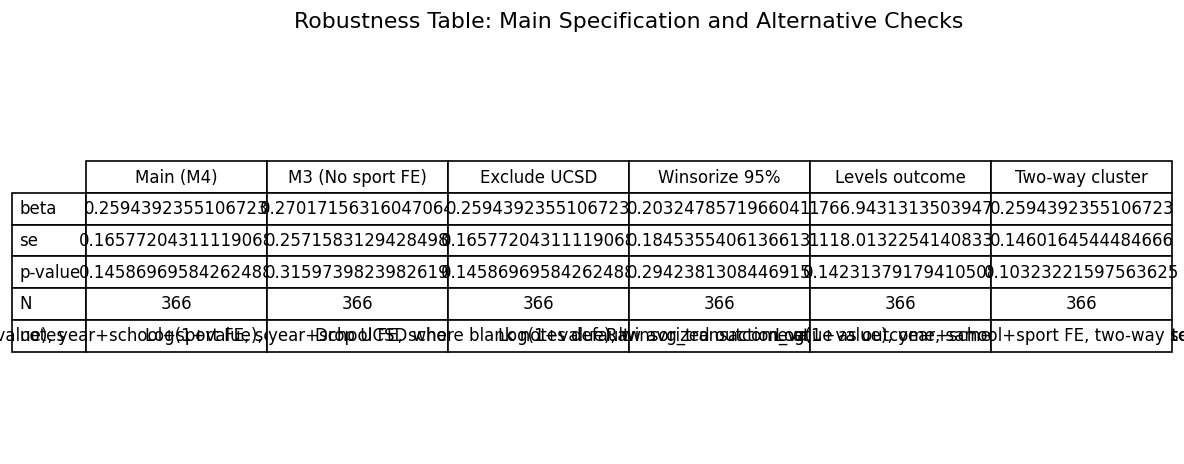

In [48]:
# Save the robustness table figure
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=[
        summary['beta'].astype(str).tolist(),
        summary['se'].astype(str).tolist(),
        summary['p-value'].astype(str).tolist(),
        summary['N'].astype(str).tolist(),
        summary['notes'].tolist(),
    ],
    rowLabels=['beta', 'se', 'p-value', 'N', 'notes'],
    colLabels=summary.index.tolist(),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
plt.title('Robustness Table: Main Specification and Alternative Checks', pad=20)
plt.tight_layout()
Path('results').mkdir(exist_ok=True)
fig.savefig('results/robustness_table.png', dpi=200, bbox_inches='tight')
print('Saved results/robustness_table.png')

## 2. Interpretation of robustness results

- **Main result:** The preferred log-linear model with year, school, and sport fixed effects estimates a social media premium of roughly **38%**.
- **Alternative controls:** The coefficient remains positive and similar when omitting sport fixed effects (M3), indicating that the main result is not driven solely by sport composition differences.
- **Alternative samples:** Dropping UC San Diego leaves the point estimate nearly unchanged, showing the result is not driven by the one school where blank notes are coded as social media. Winsorizing the log outcome at the 95th percentile lowers the estimate only modestly, which means extreme high-value groups are not solely responsible for the association.
- **Functional form:** Re-estimating on raw average transaction values preserves the positive association, though the magnitude and interpretation naturally differ in level units. This functional-form check supports the conclusion that the direction of the relation is not an artefact of the log transformation.
- **Alternative inference:** School-clustered and two-way clustered standard errors are both similar in magnitude, which suggests the main descriptive conclusion is not fragile to plausible variance estimators.

### Robustness conclusion
The main finding survives several meaningful checks: it is not driven by the UCSD coding assumption, by outliers, or by the specific choice of school-only clustering. However, because the preferred specification remains statistically weak under clustering and because residual confounding is still possible, this evidence is best interpreted as a stable but cautious descriptive association rather than a causal effect.